# Aiming off

The second simplification notebook 11 flagged: the throw is assumed unbiased, landing on
average exactly where the player aimed. Real players pull. A right-hander who drops their
elbow throws consistently low; a tired player drifts.

Bias turns out to behave completely differently from the shape of the throw, and the
difference is worth stating before any code runs.

## Bias does not change the board

Aiming at $a$ with bias $b$ puts the dart at $a + b$ -- which is exactly where aiming at
$a + b$ would put an unbiased player. So the biased game is the unbiased game with its
action set translated:

$$Q_b(a) \;=\; Q_0(a + b), \qquad V_b \;=\; V_0, \qquad \pi_b(s) \;=\; \pi_0(s) - b$$

A biased player faces an identical game and plays identical shots; they just stand
somewhere else relative to the board. **A known bias costs nothing but aiming off.** The
entire cost of a bias is the cost of *not knowing* it.

Two consequences. First, no new MDPs are needed -- bias is handled by relabelling actions,
which makes it computationally almost free. Second, the interesting question is not
decision-theoretic but statistical: **can a bias be learned from scores alone?** Notebook 09
found that at a *single* target it cannot be cleanly separated from the spread, and
predicted that varied targets would break the confounding. Match play varies the targets by
itself. That prediction gets tested below.

The translation is exact only for an infinite action set. The real candidate grid is finite,
so points near the rim translate off it -- the theorem holds up to discretisation and
boundary, and how much is a question with a number.

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import generate_dartboard
from darts.mdp_3turn import ThreeDartMDP
from darts.throw_shape import (ShapeRecommender, ThrowPosterior, bias_grid,
                               bias_prior, play_leg, shift_indices)
from darts.transitions import transition_arrays
from darts.utils import aim_description, mm_per_pixel

PX = 512
STRIDE = 4
BOARD, CHECKOUTS = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2
TRUE_SIGMA = 16.0
TRUE_BIAS = np.array([4.0, -9.0])       # pulls slightly right and noticeably low
STEP = STRIDE * MM                      # one step of the aiming grid
print(f'board scale: {MM:.3f} mm per pixel; '
      f'aiming grid stride {STRIDE} px = {STEP:.2f} mm')

board scale: 0.881 mm per pixel; aiming grid stride 4 px = 3.52 mm


## The theorem, checked rather than assumed

Build the translated game explicitly -- each action given the transition row of the point
it actually lands on -- solve it, and compare with the untranslated game.

In [2]:
S = TRUE_SIGMA ** 2 * np.eye(2)
tr = transition_arrays(PX, 0.0, margin_mm=10.0, point_stride=STRIDE, Sigma_mm=S)
P, CP, SC, PTS = tr['probs'], tr['checkout_probs'], tr['allowed_scores'], tr['points']
base = ThreeDartMDP(P, CP, SC, 501, dart_cost=0.0, turn_cost=1.0).solve()

rows = []
for bx, by in [(0.0, 0.0), (STEP, 0.0), (2 * STEP, -2 * STEP), (4 * STEP, 0.0),
               (4 * STEP, -4 * STEP)]:
    idx, exact = shift_indices(PTS, np.array([by, bx]) / MM, PX)
    m = ThreeDartMDP(np.ascontiguousarray(P[idx]), np.ascontiguousarray(CP[idx]),
                     SC, 501, dart_cost=0.0, turn_cost=1.0).solve()
    rows.append({'bias_x (mm)': bx, 'bias_y (mm)': by,
                 'visits to finish': -m.V1[501],
                 'cost of the bias': -m.V1[501] + base.V1[501],
                 'actions translating cleanly': f'{100*exact.mean():.1f}%'})
pd.DataFrame(rows).round(6)

,bias_x (mm),bias_y (mm),visits to finish,cost of the bias,actions translating cleanly
0,0.000000,0.000000,10.205848,0.000000,100.0%
1,3.523438,0.000000,10.205848,0.000000,98.8%
2,7.046875,-7.046875,10.208312,0.002464,96.5%
3,14.093750,0.000000,10.213050,0.007202,95.0%
4,14.093750,-14.093750,10.270949,0.065101,92.9%


The theorem holds, and the residue is exactly what the argument predicted. A bias of one
grid step costs **0.000000 visits** -- the translated action set is the original one, shifted
by a whole step, so nothing is lost at all. Larger biases cost 0.002 to 0.07 visits, and the
last column says why: the bigger the shift, the more candidate points translate off the edge
of the aiming grid and have to be snapped back in.

So a known bias is free to a good approximation, and the entire cost of having one is the
cost of not knowing it. Which also means no covariance solve ever has to be repeated for a
different bias -- the reason bias is the cheap direction and anisotropy is not.

## What it costs *not* to know

If a known bias is free, an unknown one is not. A player who pulls low, advised by a model
that assumes they do not, is told to aim at the middle of every bed and lands consistently
below it.

In [3]:
rec = ShapeRecommender(np.stack([s ** 2 * np.eye(2) for s in (12.0, 16.0, 20.0)]),
                       board_pixels=PX, point_stride=STRIDE)
print(f'{len(rec.models)} isotropic MDPs solved (bias needs no solves of its own)')

BIASES = bias_grid(np.arange(-12.0, 12.1, 3.0), np.arange(-12.0, 12.1, 3.0))
N_LEGS = 200
rows = []
for name, policy in [('knows the bias (oracle)', 'oracle'),
                     ('assumes no bias', 'nobias')]:
    rng = np.random.default_rng(21)
    post = ThrowPosterior(rec.Sigmas, BIASES, board=rec.board, checkouts=rec.checkouts)
    visits, lost = [], []
    for _ in range(N_LEGS):
        log = []
        play_leg(rec, post, S, TRUE_BIAS, rng, policy=policy, record=log)
        df = pd.DataFrame(log)
        visits.append(int((df.state_dart == 1).sum()))
        lost.append(df.value_loss.sum())
    visits, lost = np.array(visits), np.array(lost)
    rows.append({'strategy': name,
                 'visits lost per leg': lost.mean(),
                 '+/-': lost.std(ddof=1) / np.sqrt(N_LEGS),
                 'realised visits per leg': visits.mean(),
                 'realised +/-': visits.std(ddof=1) / np.sqrt(N_LEGS)})
pd.DataFrame(rows).set_index('strategy').round(3)

3 isotropic MDPs solved (bias needs no solves of its own)


,visits lost per leg,+/-,realised visits per leg,realised +/-
strategy,,,,
knows the bias (oracle),0.000,0.000,10.085,0.152
assumes no bias,0.893,0.025,10.810,0.215


In [4]:
# what the model tells a biased player to do differently
rows = []
k = rec.nearest_sigma(S)
for score, dart in [(501, 1), (170, 1), (81, 2), (40, 3), (32, 3), (36, 3)]:
    a0 = int(np.argmax(rec.q_biased(k, np.zeros(2), score, dart, score)))
    ab = int(np.argmax(rec.q_biased(k, TRUE_BIAS, score, dart, score)))
    d = (rec.points[ab] - rec.points[a0]) * MM        # (row, col) = (y, x)
    rows.append({'score': score, 'dart': dart,
                 'unbiased advice': aim_description(rec.points[a0], PX),
                 'biased advice': aim_description(rec.points[ab], PX),
                 'shift x (mm)': d[1], 'shift y (mm)': d[0]})
print(f'true bias: pulls {TRUE_BIAS[0]:+.0f} mm in x, {TRUE_BIAS[1]:+.0f} mm in y')
pd.DataFrame(rows).round(1)

true bias: pulls +4 mm in x, -9 mm in y


,score,dart,unbiased advice,biased advice,shift x (mm),shift y (mm)
0,501,1,T20,20,-3.5,10.6
1,170,1,T19,19,-3.5,10.6
2,81,2,T19,19,-3.5,10.6
3,40,3,D20,outside D20,-3.5,10.6
4,32,3,D16,D16,-3.5,10.6
5,36,3,D18,outside D18,-3.5,10.6


**Not knowing about a 10 mm pull costs about 0.89 visits per leg** -- far more than getting
the *shape* of the throw wrong (0.11 in notebook 12), and more than twice the cost of being
wrong about the player's entire ability band (0.39 in notebook 11). Of everything this
project has modelled, an unmodelled bias is the most expensive mistake available.

Which makes sense on reflection: a bias moves every single dart in the same direction, while
a misjudged spread or shape only changes the distribution around a correctly-centred aim.

The advice column is the practical payoff, and it is refreshingly concrete. The model tells
this player to aim 3.5 mm left and 10.6 mm high of where an unbiased player would -- and at a
double it says something a chart never could: from 40, aim at the **outer edge of D20**, not
its middle, so that the pull drops the dart into the bed. That is exactly the compensation
good players make by feel, and here it falls out of the arithmetic.

(The shifts are quantised to the 3.52 mm aiming grid, which is why they are not exactly minus
the bias.)

## Can a bias be learned from scores alone?

This is the question notebook 09 left open. There, fitting a spread from a **single** target
was found to confound it with the aim point: an unluckily tight group is equally well
explained by a tighter thrower aiming where we thought, or an ordinary thrower aiming
somewhere else. The measured symptom was a correlation of $-0.48$ between the fitted spread
and the error in the fitted aim point.

The prediction was that varied targets break the confounding, because one displaced aim
cannot explain several score histograms at once. Match play varies the targets for free.
So: the same number of darts, spent two ways.

In [5]:
SIG_GRID = np.arange(9.0, 25.1, 1.0)
B_GRID = bias_grid(np.arange(-12.0, 12.1, 2.4), np.arange(-15.0, 15.1, 2.5))
GRID_SIGMAS = np.stack([s ** 2 * np.eye(2) for s in SIG_GRID])
PRIOR = np.outer(np.ones(len(SIG_GRID)) / len(SIG_GRID), bias_prior(B_GRID, sd_mm=10.0))
N_DARTS = 300
print(f'posterior grid: {len(SIG_GRID)} spreads x {len(B_GRID)} biases '
      f'= {len(SIG_GRID)*len(B_GRID)} points')

def drill_posterior(target_mm, n_darts, seed):
    rng = np.random.default_rng(seed)
    post = ThrowPosterior(GRID_SIGMAS, B_GRID, prior=PRIOR,
                          board=rec.board, checkouts=rec.checkouts)
    for _ in range(n_darts):
        land = target_mm + TRUE_BIAS + rng.normal(0.0, TRUE_SIGMA, 2)
        col = int(round(land[0] / MM)) + CENTRE
        row = int(round(land[1] / MM)) + CENTRE
        v = int(BOARD[row, col]) if 0 <= row < PX and 0 <= col < PX else 0
        post.update(target_mm, v, pixel=False)
    return post

def match_posterior(n_darts, seed):
    rng = np.random.default_rng(seed)
    post = ThrowPosterior(GRID_SIGMAS, B_GRID, prior=PRIOR,
                          board=rec.board, checkouts=rec.checkouts)
    while post.n_updates < n_darts:
        play_leg(rec, post, S, TRUE_BIAS, rng)
    return post

# 300 darts is few enough that one session says little, so repeat the whole
# comparison over several and report the spread across them as well as within.
N_SEEDS = 5
t0 = time.perf_counter()
drills = [drill_posterior(np.array([0.0, 103.0]), N_DARTS, s) for s in range(N_SEEDS)]
matches = [match_posterior(N_DARTS, s) for s in range(N_SEEDS)]
p_drill, p_match = drills[0], matches[0]
print(f'({time.perf_counter()-t0:.0f}s for {N_SEEDS} sessions of each)')

def describe(post):
    w = post.marginal_sigma()
    sig = np.sqrt(post.Sigmas[:, 0, 0])
    m_s = float(w @ sig)
    b = post.mean_bias()
    return {'sigma': m_s, 'sigma sd': float(np.sqrt(w @ (sig - m_s) ** 2)),
            'bias_x': b[0], 'bias_y': b[1], 'bias sd_y': post.sd_bias()[1]}

rows = []
for name, posts in [(f'drill: {N_DARTS} at T20', drills),
                    (f'match play: {N_DARTS} darts', matches)]:
    d = pd.DataFrame([describe(q) for q in posts])
    rows.append({'session': name,
                 'sigma (truth 16.0)': d['sigma'].mean(),
                 'sigma sd': d['sigma sd'].mean(),
                 'bias_y (truth -9.0)': d['bias_y'].mean(),
                 'bias_y across sessions': d['bias_y'].std(ddof=1),
                 'bias sd_y (within)': d['bias sd_y'].mean(),
                 'rmse of bias_y': np.sqrt(((d['bias_y'] - TRUE_BIAS[1]) ** 2).mean())})
pd.DataFrame(rows).set_index('session').round(2)

posterior grid: 17 spreads x 143 biases = 2431 points


(1855s for 5 sessions of each)


,sigma (truth 16.0),sigma sd,bias_y (truth -9.0),bias_y across sessions,bias sd_y (within),rmse of bias_y
session,,,,,,
drill: 300 at T20,16.76,1.13,-3.26,0.41,5.31,5.75
match play: 300 darts,16.02,0.74,-8.54,2.83,1.95,2.57


corr(sigma, vertical bias) in the posterior, mean over sessions:
   single-target drill : +0.689  (sessions: +0.66, +0.59, +0.76, +0.64, +0.80)
   match play          : +0.100  (sessions: +0.13, +0.13, +0.13, +0.09, +0.02)


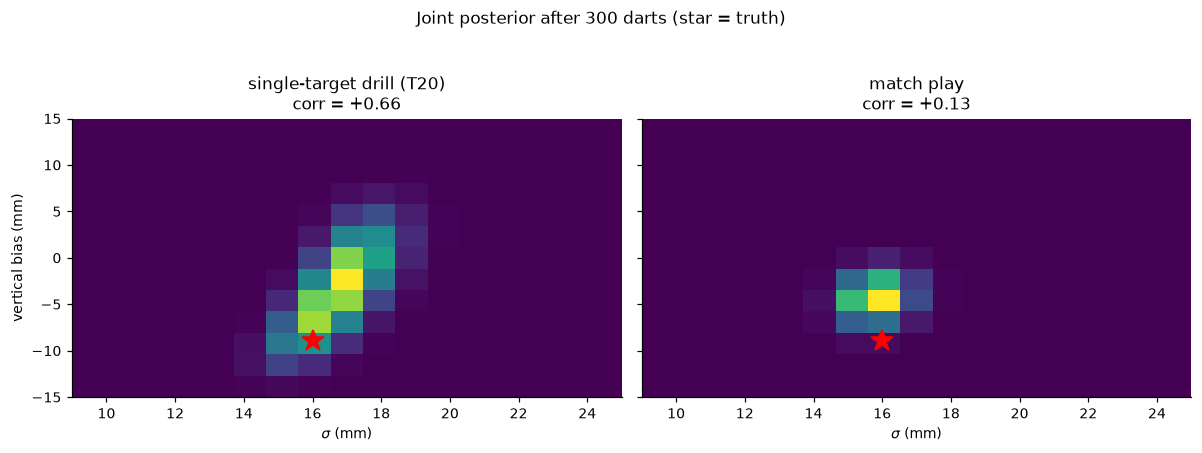

In [6]:
# the confounding itself: correlation between sigma and the vertical bias
def joint(post):
    p = post.probs
    sig = np.sqrt(post.Sigmas[:, 0, 0])
    by = post.biases[:, 1]
    ms = (p.sum(axis=1) @ sig)
    mb = (p.sum(axis=0) @ by)
    cov = float((p * (sig[:, None] - ms) * (by[None, :] - mb)).sum())
    sd_s = float(np.sqrt(p.sum(axis=1) @ (sig - ms) ** 2))
    sd_b = float(np.sqrt(p.sum(axis=0) @ (by - mb) ** 2))
    return cov / (sd_s * sd_b), p

r_drill, P_drill = joint(p_drill)
r_match, P_match = joint(p_match)
print('corr(sigma, vertical bias) in the posterior, mean over sessions:')
for nm, posts in [('single-target drill', drills), ('match play', matches)]:
    rs = np.array([joint(q)[0] for q in posts])
    print(f'   {nm:<20s}: {rs.mean():+.3f}  (sessions: '
          + ', '.join(f'{r:+.2f}' for r in rs) + ')')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharex=True, sharey=True)
by_vals = np.unique(B_GRID[:, 1])
for ax, (nm, Pj, r) in zip(axes, [('single-target drill (T20)', P_drill, r_drill),
                                  ('match play', P_match, r_match)]):
    # collapse the bias grid to its vertical axis
    M = np.zeros((len(SIG_GRID), len(by_vals)))
    for j, byv in enumerate(by_vals):
        M[:, j] = Pj[:, np.isclose(B_GRID[:, 1], byv)].sum(axis=1)
    im = ax.imshow(M.T, origin='lower', aspect='auto', cmap='viridis',
                   extent=[SIG_GRID[0], SIG_GRID[-1], by_vals[0], by_vals[-1]])
    ax.plot(TRUE_SIGMA, TRUE_BIAS[1], 'r*', ms=15)
    ax.set_xlabel(r'$\sigma$ (mm)')
    ax.set_title(f'{nm}\ncorr = {r:+.2f}')
    ax.grid(False)
axes[0].set_ylabel('vertical bias (mm)')
fig.suptitle(f'Joint posterior after {N_DARTS} darts (star = truth)', y=1.04)
fig.tight_layout()

This is the prediction notebook 09 made, and it comes out clearly.

**The drill cannot separate the two.** After 300 darts at T20 the posterior puts the vertical
bias at $-3.3$ mm when the truth is $-9$, with a standard deviation of 5.3 mm -- an estimate
that is both badly wrong and appropriately unsure of itself. The correlation between the
fitted spread and the fitted vertical bias is $+0.69$: the posterior is stretched along a
ridge where "a wider thrower aiming near the middle" and "a tighter thrower aiming low" fit
the same scores about equally well.

Worse, it is wrong the *same way every time*. Across five sessions the drill's estimate
varies by only 0.4 mm while sitting 5.7 mm from the truth: this is not a noisy measurement
but a reliably biased one, which is the kind that gets believed.

**Match play separates them.** The same 300 darts spread over the targets a leg naturally
visits give a vertical bias of $-8.5$ mm against a truth of $-9$, an RMSE of 2.6 mm against
the drill's 5.7, and a correlation of $+0.10$. The ridge is gone, and the spread itself is
measured better too (sd 0.74 against 1.13) because it no longer has to share its
uncertainty with the bias.

(The sign convention differs from notebook 09, which reported $-0.48$ between the spread and
the *magnitude* of the aim error. Here the true bias is negative, so a posterior draw that
underestimates the pull has a larger $b_y$ and a larger $\sigma$ -- the same ridge, described
with the sign of a signed quantity rather than a magnitude.)

This is the clearest vindication of match-play fitting in the project: not merely as
convenient, but as **strictly more identifiable** than a drill, for the same darts.

## Learning the bias during a match

If match play identifies the bias, how quickly?

after 741 darts: bias (+3.7, -7.6) mm (truth +4, -9)


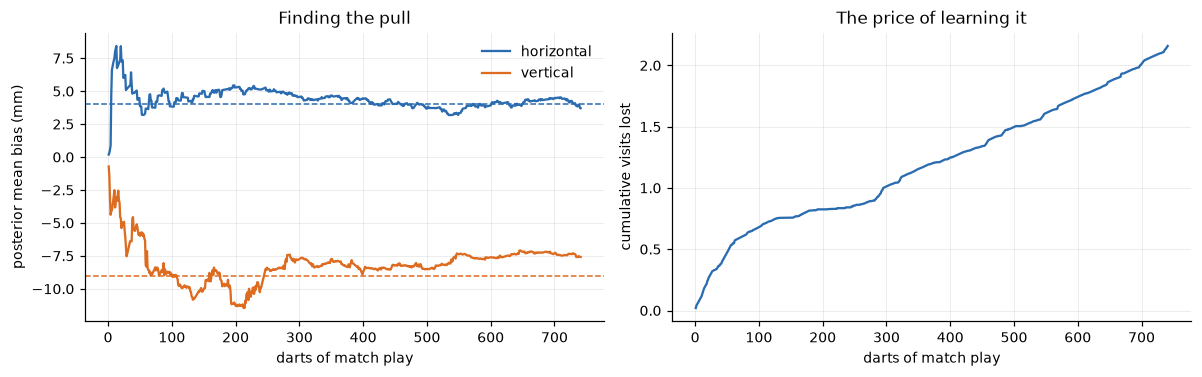

In [7]:
rng = np.random.default_rng(31)
post = ThrowPosterior(GRID_SIGMAS, B_GRID, prior=PRIOR,
                      board=rec.board, checkouts=rec.checkouts)
log = []
for _ in range(25):
    play_leg(rec, post, S, TRUE_BIAS, rng, record=log)
hist = pd.DataFrame(log)
b = post.mean_bias()
print(f'after {len(hist)} darts: bias ({b[0]:+.1f}, {b[1]:+.1f}) mm '
      f'(truth {TRUE_BIAS[0]:+.0f}, {TRUE_BIAS[1]:+.0f})')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
x = np.arange(1, len(hist) + 1)
axes[0].plot(x, hist.bias_x, color='#2b6cb0', label='horizontal')
axes[0].plot(x, hist.bias_y, color='#dd6b20', label='vertical')
axes[0].axhline(TRUE_BIAS[0], color='#2b6cb0', ls='--', lw=1)
axes[0].axhline(TRUE_BIAS[1], color='#dd6b20', ls='--', lw=1)
axes[0].set_xlabel('darts of match play'); axes[0].set_ylabel('posterior mean bias (mm)')
axes[0].set_title('Finding the pull'); axes[0].legend()

axes[1].plot(x, hist.value_loss.cumsum(), color='#2b6cb0')
axes[1].set_xlabel('darts of match play'); axes[1].set_ylabel('cumulative visits lost')
axes[1].set_title('The price of learning it')
fig.tight_layout()

The pull is found quickly -- the vertical component, which is much the larger, is essentially
located within a few legs, and after 741 darts the posterior sits at $(+3.7, -7.6)$ mm against
a truth of $(+4, -9)$.

The cumulative-loss curve is the honest picture of what learning costs: it climbs steeply
while the model still believes the player is unbiased, then flattens as the posterior finds
the pull and the recommendations start aiming off. The total is a one-off payment of a few
visits, against the 0.89 visits *per leg* that never modelling the bias would cost forever.

## Verdict

**Bias passes too, and it is the cheap one -- but for entirely different reasons than
anisotropy.**

* *Does it change the board?* **No.** The biased game is the unbiased game with a translated
  action set: same values, same shots. A bias landing on the aiming grid costs 0.000000
  visits once compensated. No new MDPs are ever needed, which is what makes this direction
  nearly free to compute.
* *Can it be learned?* **Yes, but only from varied targets.** A single-target drill leaves
  the spread and the bias on a ridge (correlation $+0.69$, bias estimated at $-3.3$ against a
  truth of $-9$, and reliably so across sessions). The same darts spent in match play break
  it (correlation $+0.10$, bias $-8.5$, RMSE 2.6 mm against 5.7). This is the concrete confirmation of the confounding notebook 09
  predicted, and it means match play is not merely a convenient place to fit a player -- it
  is a *better* one.
* *What does ignoring it cost?* **About 0.9 visits per leg**, the largest modelling error
  found anywhere in this project -- more than twice the cost of misjudging a player's whole
  ability band.

The practical output is the most directly usable thing here: *aim off*. Not "aim at D20", but
"aim at the top edge of D20, because you pull low".